In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('../data/datacleaned/matches_cleaned.csv')
deliveries = pd.read_csv('../data/datacleaned/deliveries_final.csv')
print("Loaded!")

Loaded!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('../data/datacleaned/matches_cleaned.csv')
deliveries = pd.read_csv('../data/datacleaned/deliveries_final.csv')
print("Loaded!")

Loaded!


=== TOP 10 BATSMEN ===
batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


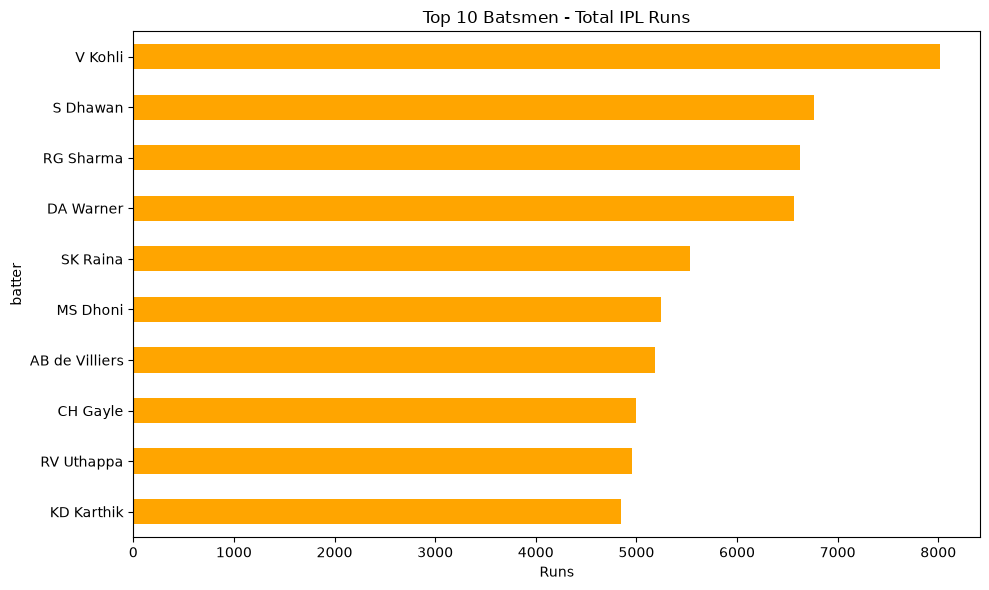

In [3]:
# KPI 2: Top Batsmen by Total Runs
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum()\
    .sort_values(ascending=False).head(10)

print("=== TOP 10 BATSMEN ===")
print(top_batsmen)

top_batsmen.sort_values().plot(kind='barh', color='orange', figsize=(10,6))
plt.title('Top 10 Batsmen - Total IPL Runs')
plt.xlabel('Runs')
plt.tight_layout()
plt.savefig('../visuals/top_batsmen.png')
plt.show()

=== TOP STRIKE RATES (min 200 balls) ===
batter
PD Salt           169.61
T Stubbs          169.46
TM Head           168.56
AD Russell        164.22
H Klaasen         161.99
TH David          158.03
SP Narine         155.89
Shashank Singh    155.51
N Pooran          154.77
LS Livingstone    154.19
dtype: float64


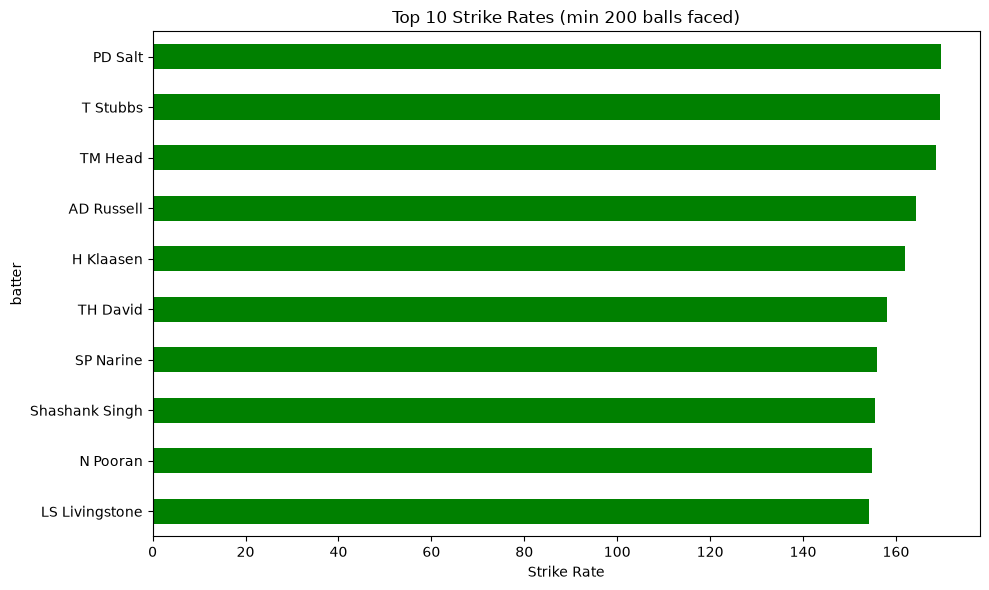

In [4]:
# KPI 3: Strike Rate (min 200 balls)
balls_faced = deliveries.groupby('batter')['ball'].count()
runs_scored = deliveries.groupby('batter')['batsman_runs'].sum()
strike_rate = (runs_scored / balls_faced * 100).round(2)
top_sr = strike_rate[balls_faced >= 200].sort_values(ascending=False).head(10)

print("=== TOP STRIKE RATES (min 200 balls) ===")
print(top_sr)

top_sr.sort_values().plot(kind='barh', color='green', figsize=(10,6))
plt.title('Top 10 Strike Rates (min 200 balls faced)')
plt.xlabel('Strike Rate')
plt.tight_layout()
plt.savefig('../visuals/strike_rates.png')
plt.show()

=== POWERPLAY AVERAGE SCORE ===
batting_team
Royal Challengers Bengaluru    56.47
Gujarat Lions                  49.40
Gujarat Titans                 45.40
Punjab Kings                   45.34
Delhi Capitals                 45.23
Sunrisers Hyderabad            45.19
Rising Pune Supergiants        45.17
Lucknow Super Giants           44.50
Kolkata Knight Riders          44.36
Rajasthan Royals               43.99
Chennai Super Kings            43.80
Kochi Tuskers Kerala           43.79
Mumbai Indians                 43.69
Royal Challengers Bangalore    42.90
Pune Warriors                  39.47
Name: batsman_runs, dtype: float64


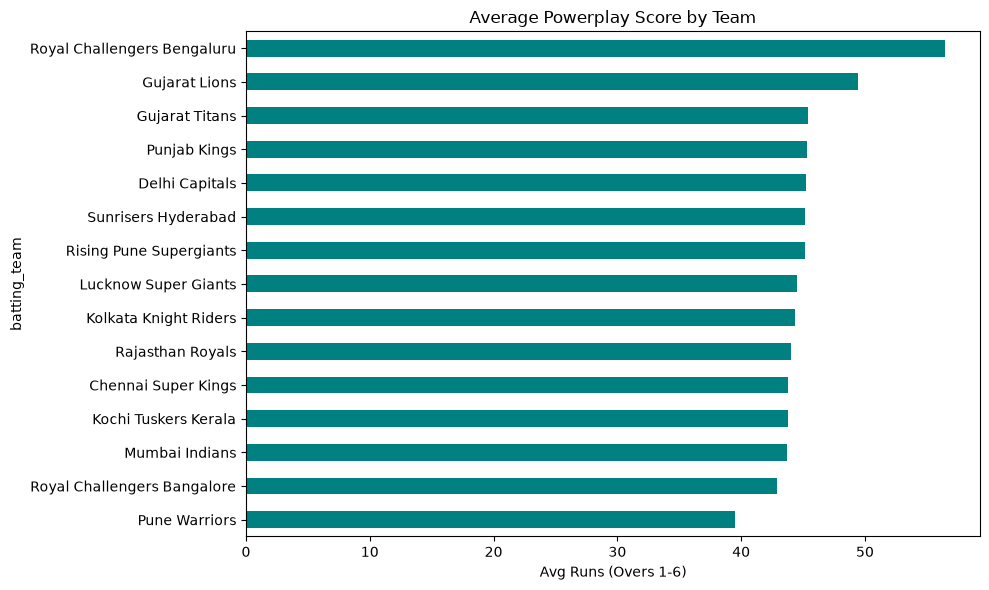

In [5]:
# KPI 4: Powerplay Average Score per Team
pp = deliveries[deliveries['phase']=='Powerplay']
pp_scores = pp.groupby(['match_id','batting_team'])['batsman_runs'].sum().reset_index()
pp_avg = pp_scores.groupby('batting_team')['batsman_runs'].mean().round(2)\
    .sort_values(ascending=False)

print("=== POWERPLAY AVERAGE SCORE ===")
print(pp_avg)

pp_avg.sort_values().plot(kind='barh', color='teal', figsize=(10,6))
plt.title('Average Powerplay Score by Team')
plt.xlabel('Avg Runs (Overs 1-6)')
plt.tight_layout()
plt.savefig('../visuals/powerplay_avg.png')
plt.show()

In [6]:
# KPI 5: Boundary Percentage
boundary_count = deliveries.groupby('batter')['is_boundary'].sum()
boundary_pct = (boundary_count / balls_faced * 100).round(2)
top_boundary = boundary_pct[balls_faced >= 200].sort_values(ascending=False).head(10)

print("=== BOUNDARY PERCENTAGE ===")
print(top_boundary)

=== BOUNDARY PERCENTAGE ===
batter
PD Salt           28.05
SP Narine         26.52
TM Head           25.33
AD Russell        25.08
YBK Jaiswal       24.02
V Sehwag          24.00
PP Shaw           22.63
P Simran Singh    22.54
RR Rossouw        21.81
CH Gayle          21.81
dtype: float64


In [7]:
# KPI 6: Player Consistency (Std Dev)
runs_per_match = deliveries.groupby(
    ['match_id','batter'])['batsman_runs'].sum().reset_index()
consistency = runs_per_match.groupby('batter')['batsman_runs']\
    .agg(['mean','std','count']).round(2)
consistency = consistency[consistency['count'] >= 20]\
    .sort_values('std').head(10)

print("=== MOST CONSISTENT BATSMEN ===")
print(consistency)

=== MOST CONSISTENT BATSMEN ===
                mean   std  count
batter                           
S Nadeem        1.95  2.01     20
RP Singh        1.86  2.16     28
Sandeep Sharma  2.16  2.70     25
I Sharma        2.71  2.94     21
JJ Bumrah       2.62  3.62     26
Mohammed Shami  3.22  4.66     23
Mohammed Siraj  5.45  4.99     20
MG Johnson      5.96  5.07     28
SL Malinga      4.40  5.12     20
TA Boult        3.77  5.23     22


In [8]:
# Export for Power BI
top_batsmen.to_csv('../data/dataprocessed/top_batsmen.csv')
win_pct.to_csv('../data/dataprocessed/team_win_pct.csv')
top_sr.to_csv('../data/dataprocessed/strike_rates.csv')
pp_avg.to_csv('../data/dataprocessed/powerplay_avg.csv')
matches.to_csv('../data/dataprocessed/matches_master.csv', index=False)
deliveries.to_csv('../data/dataprocessed/deliveries_master.csv', index=False)

print("All files exported to dataprocessed folder!")

NameError: name 'win_pct' is not defined